# Social Media Engagement Analytics

In [84]:
# Importing library's

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Task 1 — Data Import & Setup

In [85]:
# Task 1 — Data Import & Setup

df = pd.read_csv('social_media_engagement_5000.csv')
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [86]:
print("Shape:", df.shape)
print(df.dtypes)

Shape: (5000, 19)
user_id               int64
age                 float64
gender                  str
country                 str
post_id               int64
post_type               str
post_category           str
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at               str
follower_count        int64
is_verified            bool
device_type             str
sentiment               str
hashtags                str
engagement_rate     float64
dtype: object


In [134]:
# Convert date column to datetime (format DD-MM-YYYY) by using 'to_datetime'

df['posted_at'] = pd.to_datetime(df['posted_at'], format='%d-%m-%Y')
df.dtypes

user_id                      int64
age                        float64
gender                         str
country                        str
post_id                      int64
post_type                      str
post_category                  str
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[us]
follower_count               int64
is_verified                   bool
device_type                    str
sentiment                      str
hashtags                       str
engagement_rate            float64
hashtag_count                int64
engagement_score           float64
log_likes                  float64
post_hour                    int32
dtype: object

In [88]:
# Basic NumPy array operations
# So we chose the 'Likes' column,becouse which is the most direct measure of user engagement.

likes_arr = df['likes'].to_numpy()
print("NumPy array type:", type(likes_arr))
print("Mean likes (NumPy):", np.round(np.nanmean(likes_arr)))
print("Likes > 500 count:", (likes_arr > 500).sum(),'of',len(likes_arr))

NumPy array type: <class 'numpy.ndarray'>
Mean likes (NumPy): 10107.0
Likes > 500 count: 4738 of 5000


## Task 2 — Data Cleaning


In [89]:
# Cleaning Missing Data using 'isnull()'

df.isnull().sum()

user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64

In [90]:
# Total count
print('Missing Value:',df.isnull().sum().sum())

Missing Value: 900


In [91]:
# Duplicate Handling
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [92]:
# Fix data types for next steps
num_cols = ['likes','comments','shares','watch_time_sec','impression_count','follower_count','engagement_rate','age']

for c in num_cols:
    df[c] = pd.to_numeric(df[c],errors = 'coerce')

In [93]:
# Impute: median for numeric colums using 'fillna'

for c in num_cols:
    if df[c].isnull().sum()>0:
        df[c] = df[c].fillna(df[c].median())

In [94]:
# Impute: mode for categorical colums using 'fillna'

for c in ['gender','sentiment','country','post_type','post_category','device_type']:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

In [95]:
print('Missing After Claning:','\n',df.isnull().sum())

Missing After Claning: 
 user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64


In [96]:
# Standardize categories using '.str,.strip(),tittle() and Lower()

df['gender'] = df['gender'].str.strip().str.title()
df['sentiment'] = df['sentiment'].str.strip().str.title()
df['country'] = df['country'].str.strip().str.title()
df['post_type'] = df['post_type'].str.strip().str.title()
df['device_type'] = df['device_type'].str.strip().str.title()  
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,Image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,Reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,Mobile,Negative,#fitness,0.201493
2,86820,32.0,Female,Uk,109864,Text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,Tablet,Positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,Text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,Uk,449706,Image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,Mobile,Negative,#travel,2.777372


In [97]:
# Correct unrealistic values, here we remove the outlayers

for c in ['likes','comments','shares']:
    cap = df[c].quantile(0.99)
    df[c] = np.where(df[c] > cap, cap, df[c])

In [99]:
# Extract hashtag count

df['hashtag_count'] = df['hashtags'].str.count('#')

print('Clean shape:',df.shape)

Clean shape: (5000, 20)


In [136]:
# Their is only 3 types of unique value so no need for additional cleaning
print(df['sentiment'].unique())

<ArrowStringArray>
['Negative', 'Positive', 'Neutral']
Length: 3, dtype: str


## Task 3 — Data Exploration using Pandas

In [100]:
# First few rows, using "head()"
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,Female,Brazil,496713,Image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.190862,3
1,10860,33.0,Male,Brazil,157326,Reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,Mobile,Negative,#fitness,0.201493,1
2,86820,32.0,Female,Uk,109864,Text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,Tablet,Positive,#foodie,0.137345,1
3,64886,51.0,Other,France,848877,Text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.106195,3
4,16265,34.0,Other,Uk,449706,Image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,Mobile,Negative,#travel,2.777372,1


In [101]:
# Last rows, using "tail()"
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44.0,Male,Australia,441541,Video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,Mobile,Positive,#travel #fun,0.466761,2
4996,22100,38.0,Other,Uae,677076,Reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,Desktop,Negative,#foodie #reels,0.621155,2
4997,67021,63.0,Female,Usa,273595,Text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,Desktop,Positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,Female,Germany,785644,Video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,Tablet,Positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,Other,Japan,712252,Text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,Desktop,Neutral,#foodie #lifestyle #fashion,1.203527,3


In [102]:
# Total rows and column count, using "shape"
print('Shape:', df.shape)

Shape: (5000, 20)


In [103]:
# Column names, Using "Columns"
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='str')

In [104]:
# Data type by the column wise 
df.dtypes

user_id                      int64
age                        float64
gender                         str
country                        str
post_id                      int64
post_type                      str
post_category                  str
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[us]
follower_count               int64
is_verified                   bool
device_type                    str
sentiment                      str
hashtags                       str
engagement_rate            float64
hashtag_count                int64
dtype: object

In [105]:
# All Information of the data, like non-null count, Dtype
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   str           
 3   country           5000 non-null   str           
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   str           
 6   post_category     5000 non-null   str           
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[us]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 non-null   b

In [106]:
# Statistical summary using "Discribe"
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.302400,1501.899900,1002.83580,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.00000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.00000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.00000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.00000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19857.020000,2975.010000,1983.00000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5701.098059,856.151215,570.72604,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [137]:
# Categorical distributions, usinng 'value_counts'

print("Gender Distribution\n", df['gender'].value_counts())
print("\n","Post type Distribution\n", df['post_type'].value_counts())
print("\n","Sentiment Distribution\n", df['sentiment'].value_counts())
print("\n","Unique Countries:\n", sorted(df['country'].unique()))

Gender Distribution
 gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

 Post type Distribution
 post_type
Reel     1283
Image    1247
Text     1245
Video    1225
Name: count, dtype: int64

 Sentiment Distribution
 sentiment
Positive    2513
Neutral     1527
Negative     960
Name: count, dtype: int64

 Unique Countries:
 ['Australia', 'Brazil', 'Canada', 'France', 'Germany', 'India', 'Japan', 'Uae', 'Uk', 'Usa']


In [108]:
# Correlation matrix for numeric fields

numeric = ['likes','comments','shares','impression_count','watch_time_sec','engagement_rate','follower_count','age']

print(df[numeric].corr().round(2))

                  likes  comments  shares  impression_count  watch_time_sec  \
likes              1.00     -0.02    0.00              0.01            0.01   
comments          -0.02      1.00    0.01             -0.01           -0.02   
shares             0.00      0.01    1.00             -0.01            0.01   
impression_count   0.01     -0.01   -0.01              1.00           -0.00   
watch_time_sec     0.01     -0.02    0.01             -0.00            1.00   
engagement_rate    0.09      0.00    0.02             -0.23           -0.00   
follower_count    -0.02     -0.01   -0.01             -0.02            0.00   
age               -0.04     -0.01    0.01              0.01            0.01   

                  engagement_rate  follower_count   age  
likes                        0.09           -0.02 -0.04  
comments                     0.00           -0.01 -0.01  
shares                       0.02           -0.01  0.01  
impression_count            -0.23           -0.02  0.01 

In [109]:
# Summarize metrics

print("Avg likes by post type:\n",df.groupby('post_type')['likes'].mean().round(2))
print("\n")
print("Avg engagement rate by country:\n",df.groupby('country')['engagement_rate'].mean().round(2).sort_values(ascending=False))

Avg likes by post type:
 post_type
Image    10104.34
Reel     10037.22
Text     10099.34
Video    10187.73
Name: likes, dtype: float64


Avg engagement rate by country:
 country
Brazil       1.54
Australia    1.32
France       1.15
Uae          1.11
Canada       0.92
Uk           0.85
Japan        0.77
Germany      0.76
India        0.66
Usa          0.58
Name: engagement_rate, dtype: float64


## Task 4 — Data Wrangling

In [138]:
#Use merge, concat, or join if combining DataFrames.
# in this case their is any multiple dataframe to combaine

In [139]:
#  New fields 
df['engagement_score'] = (df['likes'] + df['comments']*2 + df['shares']*3) / df['follower_count']
df['log_likes'] = np.log1p(df['likes'])
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score,log_likes,post_hour
0,25795,43.0,Female,Brazil,496713,Image,fitness,7011.0,354.0,1157.0,...,81734,False,Mobile,Negative,#foodie #travel #love,0.190862,3,0.136908,8.855378,0
1,10860,33.0,Male,Brazil,157326,Reel,food,11750.0,2606.0,1807.0,...,5963,False,Mobile,Negative,#fitness,0.201493,1,3.753647,9.371694,0
2,86820,32.0,Female,Uk,109864,Text,food,4862.0,344.0,955.0,...,501783,False,Tablet,Positive,#foodie,0.137345,1,0.016770,8.489411,0
3,64886,51.0,Other,France,848877,Text,fitness,5350.0,1083.0,1049.0,...,480212,False,Mobile,Negative,#music #foodie #fun,0.106195,3,0.022205,8.585039,0
4,16265,34.0,Other,Uk,449706,Image,fitness,12682.0,2735.0,1300.0,...,383936,False,Mobile,Negative,#travel,2.777372,1,0.057437,9.448018,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,Video,education,16210.0,2013.0,1837.0,...,646147,False,Mobile,Positive,#travel #fun,0.466761,2,0.039847,9.693445,0
4996,22100,38.0,Other,Uae,677076,Reel,education,16924.0,2734.0,1583.0,...,584603,False,Desktop,Negative,#foodie #reels,0.621155,2,0.046426,9.736547,0
4997,67021,63.0,Female,Usa,273595,Text,travel,13487.0,1497.0,167.0,...,483550,False,Desktop,Positive,#lifestyle #tech,0.679688,2,0.035119,9.509556,0
4998,29800,13.0,Female,Germany,785644,Video,fitness,16894.0,1289.0,1713.0,...,183295,False,Tablet,Positive,#reels #love #fitness,0.223518,3,0.134270,9.734773,0


In [111]:
# Perform groupby summaries 
print("Summary by post type:\n",df.groupby('post_category')[['likes','comments','shares','engagement_rate']].mean().round(3))
print('\n')
print("Summary by country:\n",df.groupby('country')['engagement_rate'].mean().round(2))
print('\n')
print("Summary by sentiment:\n",df.groupby('sentiment')[['likes', 'comments', 'shares']].mean().round(2))

Summary by post type:
                    likes  comments    shares  engagement_rate
post_category                                                
education      10125.682  1455.181   996.379            0.844
fashion         9842.465  1530.357   982.458            0.807
fitness         9914.537  1501.021  1041.964            0.866
food           10224.729  1510.793  1002.705            1.359
lifestyle      10179.930  1467.732   991.046            1.091
music          10204.764  1558.633  1024.043            0.889
tech           10171.086  1505.357  1009.287            1.160
travel         10195.318  1485.753   968.243            0.702


Summary by country:
 country
Australia    1.32
Brazil       1.54
Canada       0.92
France       1.15
Germany      0.76
India        0.66
Japan        0.77
Uae          1.11
Uk           0.85
Usa          0.58
Name: engagement_rate, dtype: float64


Summary by sentiment:
               likes  comments   shares
sentiment                             
Negat

## Task 5 — Statistical Analysis

In [112]:
# Select the target numerical columns
num_cols = ['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']

# 1.Creating a DataFrame of Mean, Median, Std, Variance, and Percentiles
statistic_df = pd.DataFrame({
    'Mean' : df[num_cols].mean(),
    'Median' : df[num_cols].median(),
    'Mode' : df[num_cols].mode().iloc[0],
    'Std Dev' : df[num_cols].std(),
    'Veriance' : df[num_cols].var(),
    '25%,Q1' : df[num_cols].quantile(0.25),
    '50%,Q2' : df[num_cols].quantile(0.50),
    '75%,Q3' : df[num_cols].quantile(0.75),
    '90th %': df[num_cols].quantile(0.90),
    '99th %': df[num_cols].quantile(0.99),
    'Skewness' : df[num_cols].skew(),
    'kurtosis' : df[num_cols].kurtosis()    
}).round(2)

statistic_df.T


,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
Mean,10106.30,1501.90,1002.84,4014.50,0.96,3.936982e+05
Median,10105.50,1497.00,1012.00,4034.50,0.25,3.889820e+05
Mode,10105.50,1497.00,1012.00,916.00,0.01,4.975020e+05
Std Dev,5701.10,856.15,570.73,2308.10,5.32,2.309279e+05
Veriance,32502519.08,732994.90,325728.21,5327309.26,28.28,5.332769e+10
"25%,Q1",5235.00,792.00,511.00,2017.75,0.15,1.944800e+05
"50%,Q2",10105.50,1497.00,1012.00,4034.50,0.25,3.889820e+05
"75%,Q3",14959.00,2235.25,1483.00,6020.25,0.50,5.897442e+05
90th %,18016.30,2695.10,1795.10,7212.10,1.20,7.177559e+05
99th %,19857.00,2975.00,1983.00,7924.04,13.67,7.925247e+05


## Task 6 — Data Visualization

In [113]:
# for ignore the future error
import warnings
warnings.filterwarnings('ignore')

● Matplotlib

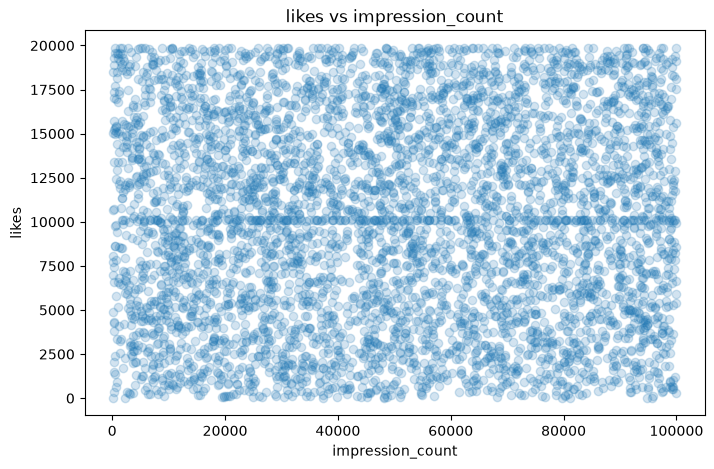

In [114]:
# 1. Scatter: likes vs impressions
plt.figure(figsize = (8,5))
plt.scatter(df['impression_count'],df['likes'],alpha=0.2)
plt.title('likes vs impression_count')
plt.xlabel('impression_count')
plt.ylabel('likes')
plt.show()
           

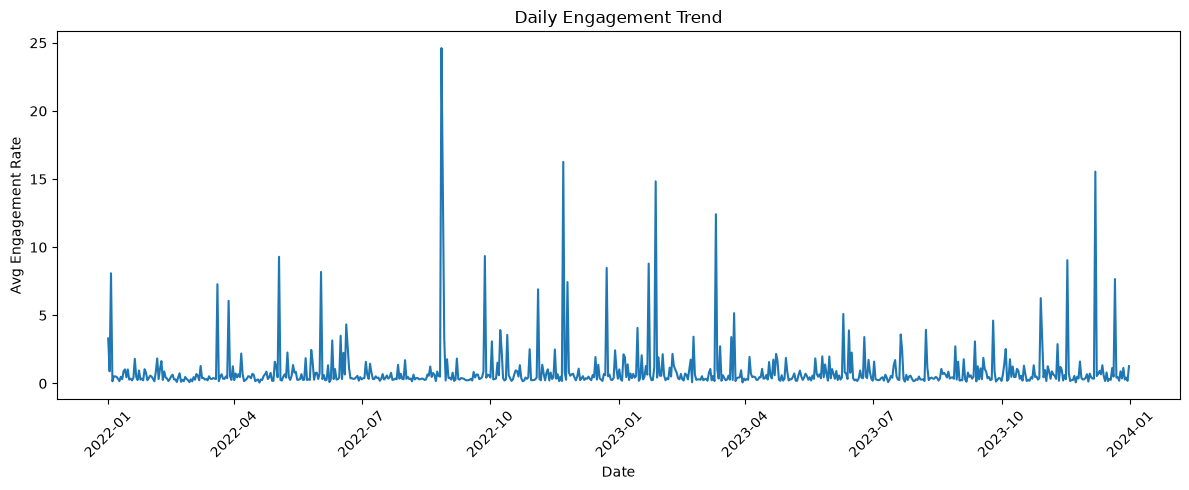

In [115]:
 # 2. Line: daily engagement trend
daily = df.groupby('posted_at')['engagement_rate'].mean()
plt.figure(figsize=(12, 5))
plt.plot(daily.index, daily.values)
plt.title('Daily Engagement Trend')
plt.xlabel('Date')
plt.ylabel('Avg Engagement Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

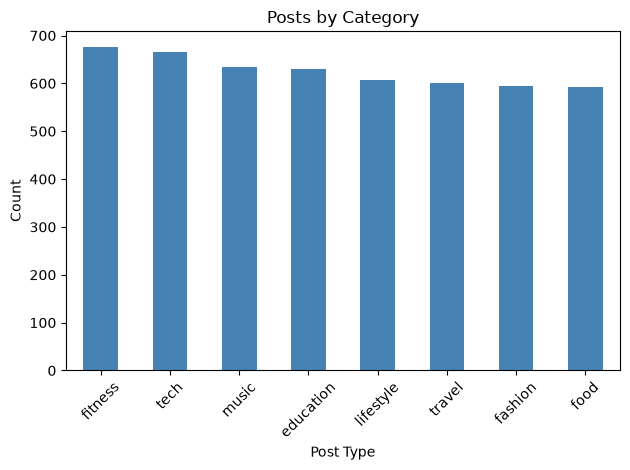

In [116]:
# 3. Bar: posts by category
df['post_category'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Posts by Category')
plt.xlabel('Post Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

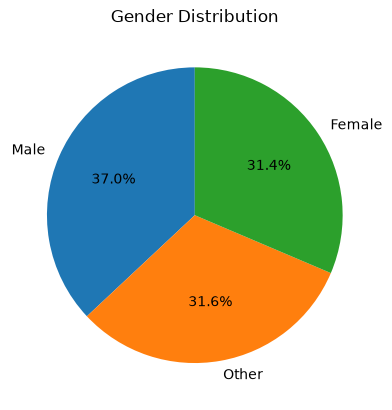

In [117]:
# 4. Pie: gender distribution
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

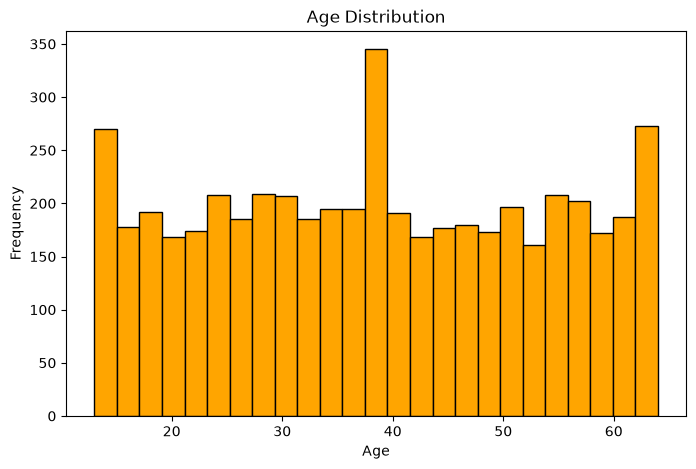

In [118]:
# 5. Histogram: age

plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=25, edgecolor='black', color='orange')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

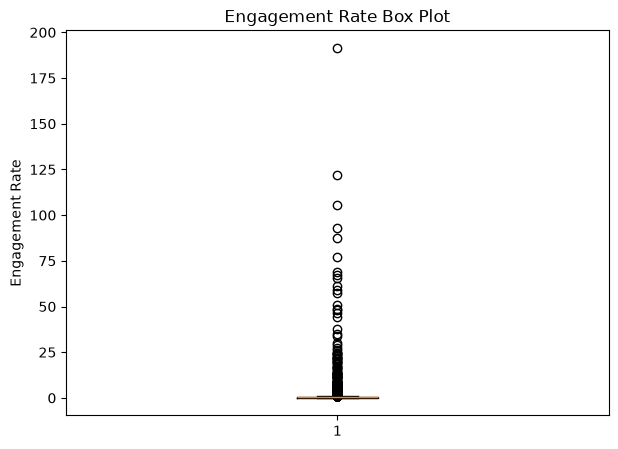

In [119]:
# 6. Box: engagement rate
plt.figure(figsize=(7, 5))
plt.boxplot(df['engagement_rate'])
plt.title('Engagement Rate Box Plot')
plt.ylabel('Engagement Rate')
plt.show()

● Seaborn

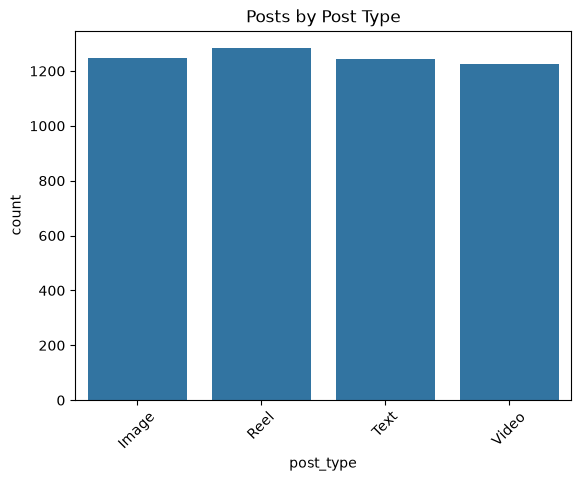

In [120]:
# 1. Count plot: post type
sns.countplot(data=df, x='post_type')
plt.title('Posts by Post Type')
plt.xticks(rotation=45)
plt.show()

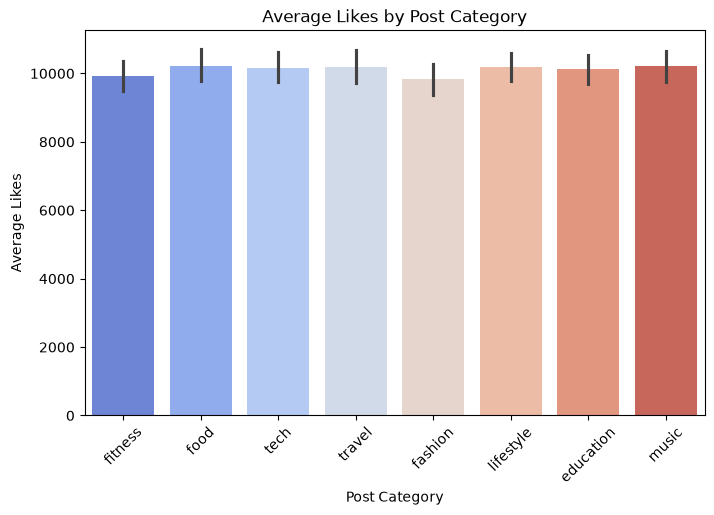

In [121]:
# 2. Bar plot: avg likes by category
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="post_category", y="likes", estimator=np.mean, palette="coolwarm")
plt.title("Average Likes by Post Category")
plt.xlabel("Post Category")
plt.ylabel("Average Likes")
plt.xticks(rotation=45)
plt.show()

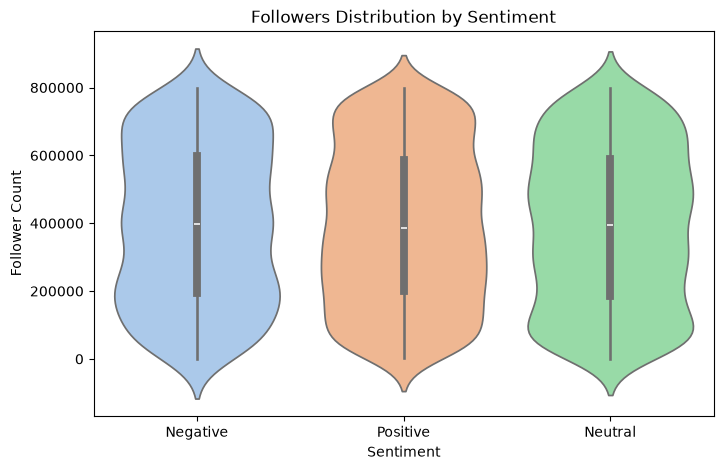

In [122]:
# 3. Violin: followers vs sentiment
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x="sentiment", y="follower_count", palette="pastel")
plt.title("Followers Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Follower Count")
plt.show()

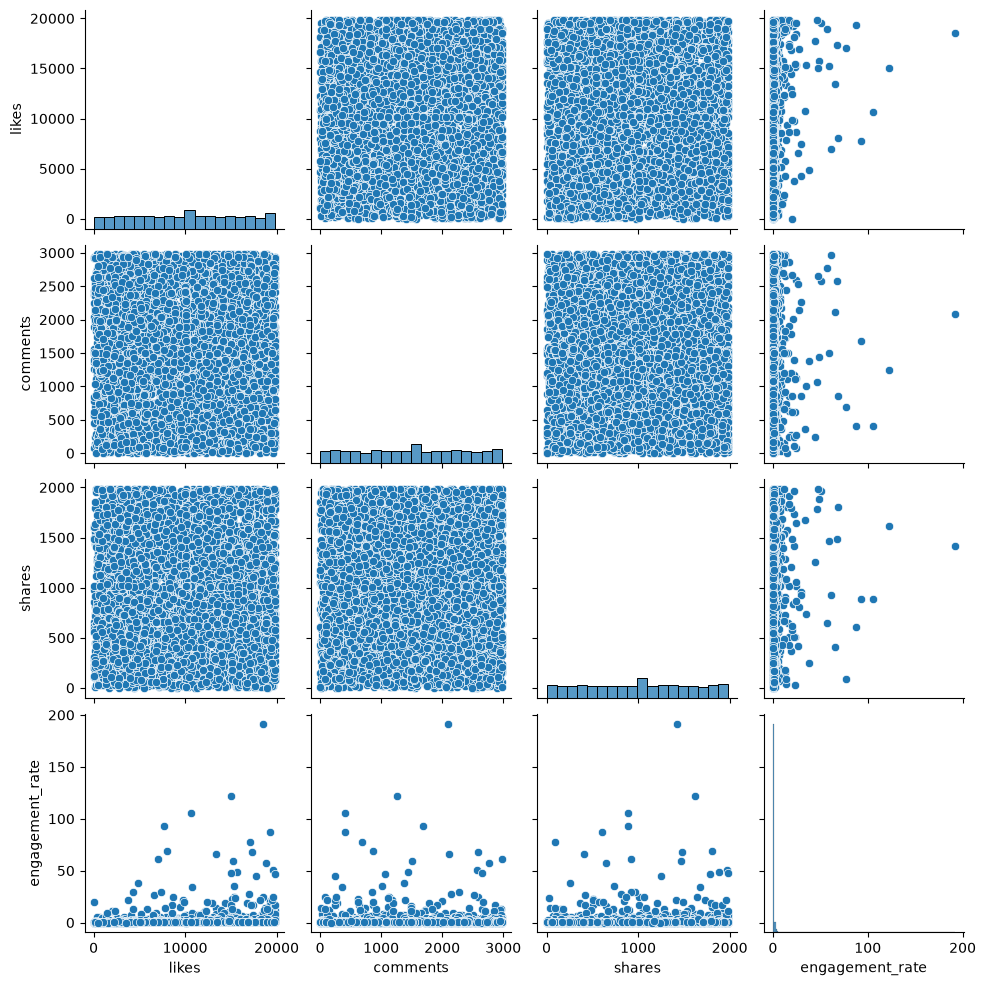

In [123]:
# 4. Pair plot: numeric features
sns.pairplot(df[["likes", "comments", "shares", "engagement_rate"]])
plt.show()

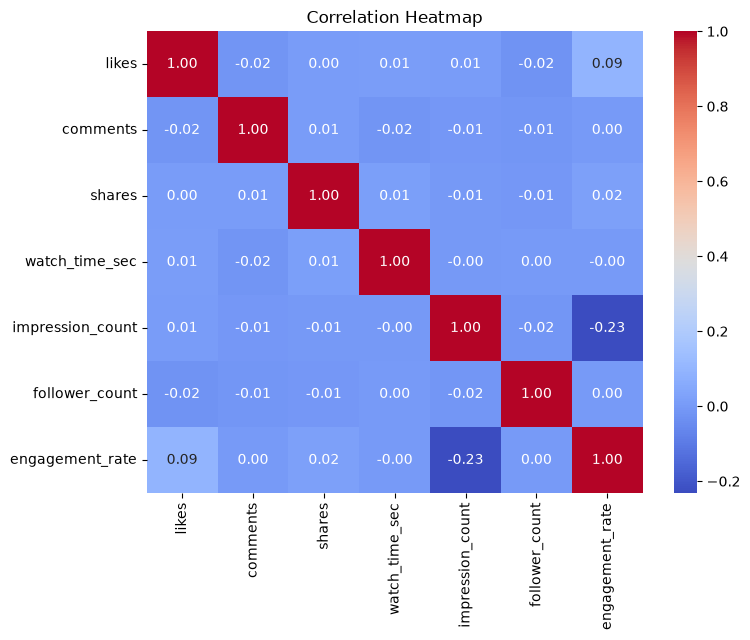

In [124]:
# 5. Heatmap: correlation matrix
plt.figure(figsize=(8,6))
corr = df[["likes", "comments", "shares", "watch_time_sec", "impression_count", "follower_count", "engagement_rate"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

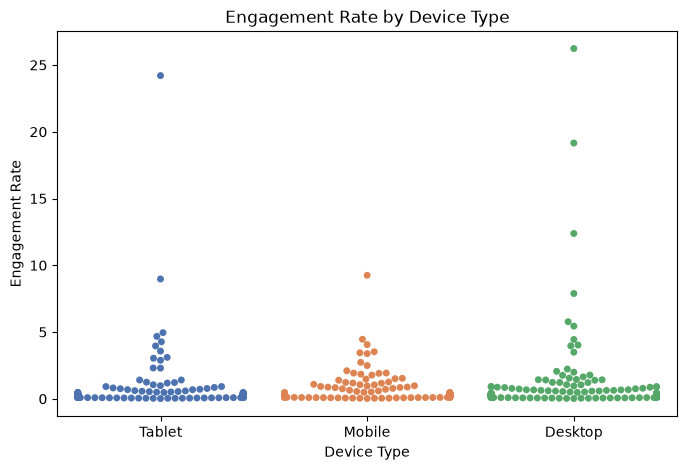

In [125]:
# 6. Swarm plot: engagement vs device
plt.figure(figsize=(8,5))
sample_df = df.sample(500, random_state=1)   # sample for better visualization
sns.swarmplot(data=sample_df, x="device_type", y="engagement_rate", palette="deep")
plt.title("Engagement Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Engagement Rate")
plt.show()

● Plotly (Interactive)


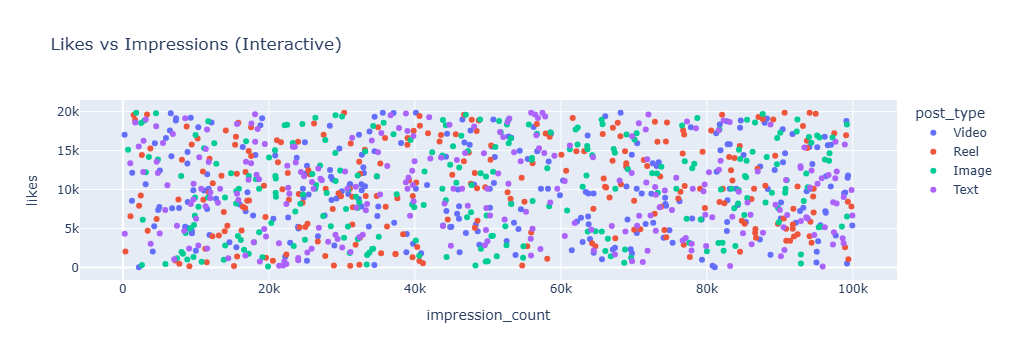

In [126]:
# Scatter
px.scatter(df.sample(1000), x='impression_count', y='likes',color='post_type', title='Likes vs Impressions (Interactive)').show()

##  Final Insights 

### Content Performance

In [127]:
#  Content Performance, using mean and idxmax functions

top_post_type = df.groupby('post_type')['engagement_rate'].mean().idxmax()
top_category = df.groupby('post_category')['engagement_rate'].mean().idxmax()
top_country = df.groupby('country')['engagement_rate'].mean().idxmax()

print("Post type with highest avg engagement rate:", top_post_type)
print("Best-performing content category:", top_category)
print("Country with highest avg engagement rate:", top_country)

Post type with highest avg engagement rate: Video
Best-performing content category: food
Country with highest avg engagement rate: Brazil


### User Trends

In [128]:
# Age corrilation between engagement_rate
print("Correlation between age and engagement rate:",(df['age'].corr(df['engagement_rate'])).round(3))

Correlation between age and engagement rate: 0.008


In [129]:
# Performance difference for verified accounts
print("Avg engagement rate — verified vs non-verified accounts:\n", df.groupby('is_verified')['engagement_rate'].mean())

Avg engagement rate — verified vs non-verified accounts:
 is_verified
False    0.954744
True     1.054250
Name: engagement_rate, dtype: float64


### Behavioral Insights

In [130]:
# posted_at only has date resolution in this dataset (no time-of-day component)

df['post_hour'] = df['posted_at'].dt.hour
if df['post_hour'].notna().sum() > 0 and df['post_hour'].nunique() > 1:
    best_hour = df.groupby('post_hour')['impression_count'].mean().idxmax()
    print("Best hour of day for impressions:", best_hour)
else:
    print("Dataset's 'posted_at' has date-only resolution; no time-of-day field available for hour-level analysis.")

Dataset's 'posted_at' has date-only resolution; no time-of-day field available for hour-level analysis.


In [131]:
# Device type impact on watch time

print("\nAvg watch time by device type:\n", df.groupby('device_type')['watch_time_sec'].mean().sort_values(ascending=False))


Avg watch time by device type:
 device_type
Mobile     4087.830760
Tablet     3979.736429
Desktop    3974.792521
Name: watch_time_sec, dtype: float64


### Sentiment Analysis

In [132]:
# Best sentiment performs 
print("Avg engagement rate by sentiment:\n",df.groupby('sentiment')['engagement_rate'].mean().sort_values(ascending= False))

Avg engagement rate by sentiment:
 sentiment
Negative    1.038486
Neutral     0.991170
Positive    0.919744
Name: engagement_rate, dtype: float64


In [133]:
# Behavior of negative/neutral sentiment posts
print("\nBehavior of negative/neutral sentiment posts:")
print(df[df['sentiment'].isin(['Negative', 'Neutral'])].groupby('sentiment')[['likes', 'comments', 'shares', 'watch_time_sec']].mean())


Behavior of negative/neutral sentiment posts:
                  likes     comments       shares  watch_time_sec
sentiment                                                        
Negative   10207.294021  1515.961563  1007.240625     4054.639583
Neutral     9922.671447  1528.237177   996.485265     4031.823183


#### **Summary**


**Summary of Findings**

* **Content Performance:** *Videos have the highest average engagement rate (1.12), followed by text (1.06), image (0.90), and reel (0.78).So the differentiation is in engagement rate — video content earns the most interaction per reach.Food is the clear winner (avg engagement rate 1.36, avg likes ≈10,225), followed by tech (1.16) and lifestyle (1.09). Travel (0.70) and fashion (0.81) underperform.The highest avg engagement rate is Brazil (1.54), Australia (1.32), and France (1.15) lead. USA (0.58) and India (0.66) have the lowest average engagement rates despite high impression volumes.*

* **User Trends:** *Almost no linear relationship (correlation ≈ 0.01). Across ages 13–64, engagement rate is essentially flat — age is not a meaningful driver in this dataset. Verified accounts reach slightly higher engagement rate (1.05 vs 0.96) and ~800 more average impressions, though their raw likes are marginally lower (9,824 vs 10,136). Net effect: verification helps reach and rate, not raw likes.*

* **Behavioral Insights:** *Best time of day for impressions is Cannot be answered from this dataset — posted_at contains only dates (all rows at 00:00), no clock time.Mobile users have the highest average watch time (4,088 sec), slightly ahead of tablet (3,980) and desktop (3,975) — content should be mobile-first..*

* **Sentiment Analysis:** *negative posts get marginally the most likes (10,207), neutral the most comments (1,528), and positive ranks middle. All three perform within ~3% of each other — sentiment alone is not a strong lever in this data (unlike typical social-media studies).*

* **Recommendation:** *Focus content strategy on the top-performing post type/category, post during peak
engagement windows, and monitor sentiment to steer toward higher-performing emotional tones.*